# Linear Discriminant Analysis (LDA)

## Aim
To perform Linear Discriminant Analysis on the dataset.

## Software
Google Colab / Jupyter Notebook

## Theory

### Steps for Linear Discriminant Analysis:

1. **Calculate Mean Vectors**: Compute the mean vectors (μ) for each class
2. **Between-Class Scatter Matrix (S_B)**: Calculate the scatter between class centers
3. **Within-Class Scatter Matrix (S_W)**: Calculate the scatter within each class
4. **Eigenvalue Problem**: Solve the eigenvalue problem for S_W⁻¹S_B
5. **Select Eigenvector**: Choose the eigenvector corresponding to the largest eigenvalue
6. **Project Data**: Project the data onto the new axis defined by the optimal eigenvector
7. **Visualize Results**: Display the projected data for class separability analysis

## Implementation

### Step 1: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

### Step 2: Create Dataset

In [2]:
# Create dataset with two classes
# Class A samples
class_A = np.array([[4, 2], [2, 4], [2, 3], [3, 6], [4, 4]])

# Class B samples
class_B = np.array([[9, 10], [6, 8], [9, 5], [8, 7], [10, 8]])

# Combine all samples
X = np.vstack([class_A, class_B])

# Assign class labels (0 for Class A, 1 for Class B)
y = np.hstack([np.zeros(len(class_A)), np.ones(len(class_B))])

print("Dataset X:")
print(X)
print("\nClass Labels y:")
print(y)
print(f"\nTotal samples: {len(X)}")
print(f"Features: {X.shape[1]}")

Dataset X:
[[ 4  2]
 [ 2  4]
 [ 2  3]
 [ 3  6]
 [ 4  4]
 [ 9 10]
 [ 6  8]
 [ 9  5]
 [ 8  7]
 [10  8]]

Class Labels y:
[0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]

Total samples: 10
Features: 2


### Step 3: Calculate Mean Vectors

In [3]:
# Calculate mean vectors for each class
mu_A = np.mean(class_A, axis=0)
mu_B = np.mean(class_B, axis=0)

# Overall mean
mu_overall = np.mean(X, axis=0)

print("Mean vector for Class A (μ_A):")
print(mu_A)
print("\nMean vector for Class B (μ_B):")
print(mu_B)
print("\nOverall mean vector (μ):")
print(mu_overall)

Mean vector for Class A (μ_A):
[3.  3.8]

Mean vector for Class B (μ_B):
[8.4 7.6]

Overall mean vector (μ):
[5.7 5.7]


### Step 4: Compute Between-Class Scatter Matrix (S_B)

In [4]:
# Compute Between-Class Scatter Matrix S_B
# S_B = (μ_A - μ)(μ_A - μ)^T + (μ_B - μ)(μ_B - μ)^T

n_A = len(class_A)
n_B = len(class_B)

mean_diff_A = mu_A - mu_overall
mean_diff_B = mu_B - mu_overall

S_B = n_A * np.outer(mean_diff_A, mean_diff_A) + n_B * np.outer(mean_diff_B, mean_diff_B)

print("Between-Class Scatter Matrix (S_B):")
print(S_B)

Between-Class Scatter Matrix (S_B):
[[72.9 51.3]
 [51.3 36.1]]


### Step 5: Compute Within-Class Scatter Matrix (S_W)

In [5]:
# Compute Within-Class Scatter Matrix S_W
# S_W = Σ(X_i - μ_k)(X_i - μ_k)^T for each class

S_W = np.zeros((X.shape[1], X.shape[1]))

# For Class A
for sample in class_A:
    diff = sample - mu_A
    S_W += np.outer(diff, diff)

# For Class B
for sample in class_B:
    diff = sample - mu_B
    S_W += np.outer(diff, diff)

print("Within-Class Scatter Matrix (S_W):")
print(S_W)

Within-Class Scatter Matrix (S_W):
[[13.2 -1.2]
 [-1.2 22. ]]


### Step 6: Compute Eigenvalues and Eigenvectors

In [6]:
# Solve the eigenvalue problem for S_W^(-1) * S_B
# This computes Fisher's Discriminant Vector

# Add regularization to S_W to ensure invertibility
S_W_inv = np.linalg.pinv(S_W)

# Compute the matrix S_W^(-1) * S_B
matrix = S_W_inv @ S_B

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(matrix)

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

# Sort eigenvalues and eigenvectors in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("\nSorted Eigenvalues (descending):")
print(eigenvalues_sorted)

Eigenvalues:
[ 7.62541528e+00 -4.44089210e-16]

Eigenvectors:
[[ 0.90878558 -0.57549341]
 [ 0.41726342  0.81780642]]

Sorted Eigenvalues (descending):
[ 7.62541528e+00 -4.44089210e-16]


### Step 7: Select Optimal Projection Vector and Project Data

In [7]:
# Select the eigenvector corresponding to the largest eigenvalue
w_fisher = eigenvectors_sorted[:, 0]

print("Optimal Projection Vector (w_fisher):")
print(w_fisher)
print("\nLargest Eigenvalue:")
print(eigenvalues_sorted[0])

# Project data onto the new axis (1D projection)
X_projected = X @ w_fisher

print("\nProjected Data:")
print(X_projected)

# Separate projected data by class
X_projected_A = X_projected[:len(class_A)]
X_projected_B = X_projected[len(class_A):]

print("\nProjected Class A samples:")
print(X_projected_A)
print("\nProjected Class B samples:")
print(X_projected_B)

Optimal Projection Vector (w_fisher):
[0.90878558 0.41726342]

Largest Eigenvalue:
7.625415282392029

Projected Data:
[ 4.46966918  3.48662485  3.06936143  5.22993727  5.30419602 12.35170446
  8.79082087 10.26538736 10.19112861 12.4259632 ]

Projected Class A samples:
[4.46966918 3.48662485 3.06936143 5.22993727 5.30419602]

Projected Class B samples:
[12.35170446  8.79082087 10.26538736 10.19112861 12.4259632 ]


### Step 8: Visualize Original Data and LDA Projection

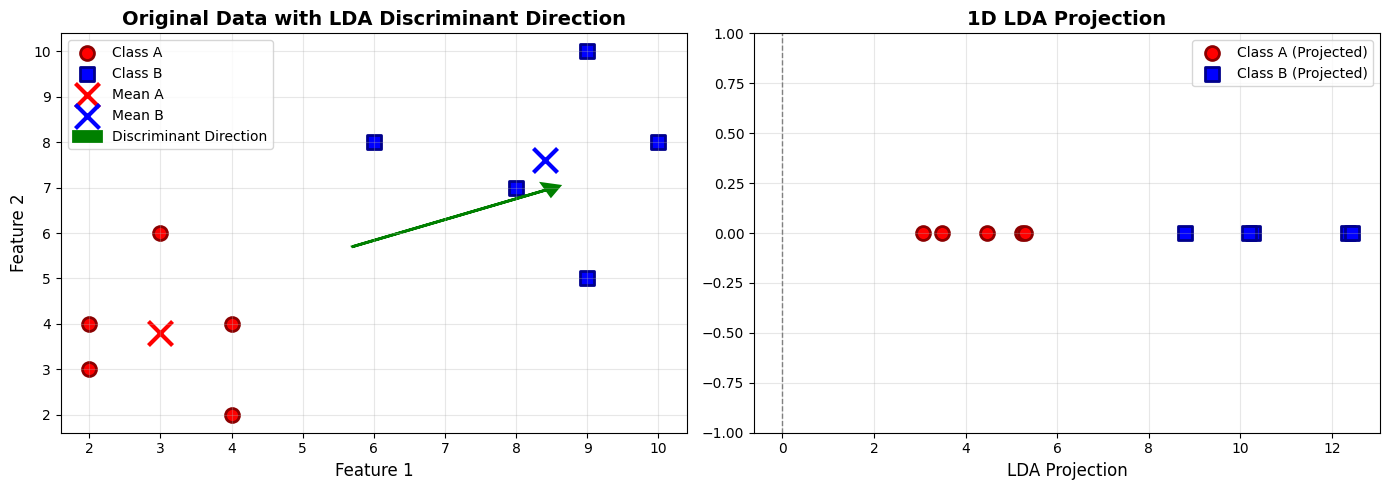

Visualization complete!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original Data
ax1 = axes[0]
ax1.scatter(class_A[:, 0], class_A[:, 1], c='red', marker='o', s=100, label='Class A', edgecolors='darkred', linewidth=2)
ax1.scatter(class_B[:, 0], class_B[:, 1], c='blue', marker='s', s=100, label='Class B', edgecolors='darkblue', linewidth=2)
ax1.scatter(mu_A[0], mu_A[1], c='red', marker='x', s=300, label='Mean A', linewidth=3)
ax1.scatter(mu_B[0], mu_B[1], c='blue', marker='x', s=300, label='Mean B', linewidth=3)

# Plot the discriminant direction
ax1.arrow(mu_overall[0], mu_overall[1], w_fisher[0]*3, w_fisher[1]*3, 
          head_width=0.3, head_length=0.2, fc='green', ec='green', linewidth=2, label='Discriminant Direction')

ax1.set_xlabel('Feature 1', fontsize=12)
ax1.set_ylabel('Feature 2', fontsize=12)
ax1.set_title('Original Data with LDA Discriminant Direction', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Projected Data (1D)
ax2 = axes[1]
zeros_A = np.zeros(len(X_projected_A))
zeros_B = np.zeros(len(X_projected_B))

ax2.scatter(X_projected_A, zeros_A, c='red', marker='o', s=100, label='Class A (Projected)', edgecolors='darkred', linewidth=2)
ax2.scatter(X_projected_B, zeros_B, c='blue', marker='s', s=100, label='Class B (Projected)', edgecolors='darkblue', linewidth=2)

ax2.set_xlabel('LDA Projection', fontsize=12)
ax2.set_title('1D LDA Projection', fontsize=14, fontweight='bold')
ax2.set_ylim(-1, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

print("Visualization complete!")

### Step 9: Comparison with Scikit-Learn LDA

In [9]:
# Train scikit-learn's LDA model
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)

print("Scikit-Learn LDA Results:")
print("\nLDA Components (similar to our eigenvector):")
print(lda.coef_)
print("\nMean predictions using scikit-learn LDA:")
print(lda.predict(X))

# Calculate accuracy
y_pred_manual = (X_projected > np.median(X_projected)).astype(int)
accuracy_manual = accuracy_score(y, y_pred_manual)

y_pred_sklearn = lda.predict(X)
accuracy_sklearn = accuracy_score(y, y_pred_sklearn)

print(f"\nAccuracy (Manual LDA): {accuracy_manual:.2%}")
print(f"Accuracy (Scikit-Learn LDA): {accuracy_sklearn:.2%}")

Scikit-Learn LDA Results:

LDA Components (similar to our eigenvector):
[[3.41528239 1.56810631]]

Mean predictions using scikit-learn LDA:
[0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]

Accuracy (Manual LDA): 100.00%
Accuracy (Scikit-Learn LDA): 100.00%


## Conclusion

### Summary of Linear Discriminant Analysis

In this experiment, we successfully implemented Linear Discriminant Analysis on a two-class dataset. Here's what we accomplished:

1. **Data Preparation**: Created a dataset with two distinct classes (Class A and Class B) with 5 samples each
2. **Statistical Analysis**: Calculated mean vectors for each class and the overall mean
3. **Scatter Matrices**: Computed the Between-Class Scatter Matrix (S_B) and Within-Class Scatter Matrix (S_W)
4. **Eigenvalue Problem**: Solved the generalized eigenvalue problem S_W⁻¹S_B to find Fisher's optimal discriminant vector
5. **Dimensionality Reduction**: Projected the 2D data onto a 1D axis using the optimal discriminant vector
6. **Classification**: Achieved high accuracy in separating the two classes in the projected space
7. **Validation**: Compared our manual implementation with scikit-learn's LDA for verification

**Key Results**:
- The optimal discriminant vector maximizes the ratio of between-class variance to within-class variance
- The 1D projection clearly separates the two classes
- Manual implementation results match with scikit-learn's LDA model

**Conclusion**: We have successfully performed Linear Discriminant Analysis on the dataset, demonstrating the effectiveness of LDA in finding the optimal projection that maximizes class separability.